In [1]:
import keras
import keras_tuner
import os
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error

/Users/benedikt/Documents/Master/SoSe 25/Deep Learning for Text Analytics/Coding/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


# Reading the Given Training Datasets and Brute Random Split

Set the paths to the correct directory

In [2]:
x_train_dir = './resources/train_X.csv'
y_train_dir = './resources/train_y.csv'
x_test_dir = './resources/test_X.csv'


x_train_raw = pd.read_csv(x_train_dir)
x_train_raw = x_train_raw.drop(columns=[x_train_raw.columns[0]])

y_train_raw = pd.read_csv(y_train_dir)
y_train_raw = y_train_raw.drop(columns=[y_train_raw.columns[0]])

x_test = pd.read_csv(x_test_dir)
x_test = x_test.drop(columns=[x_test.columns[0]])

# Try random split and compare
x_train, x_val, y_train, y_val = train_test_split(x_train_raw, 
                                                  y_train_raw, 
                                                  test_size=0.3, 
                                                  random_state=42,
                                                  shuffle = True)


## Scaling

Scale the datasets with a scaler fitted only with training data to avoid data leakage. Used scaler in this case is StandardScaler()

In [3]:

x_scaler = StandardScaler()
x_scaler.fit(x_train)

x_train_scaled, x_val_scaled = x_scaler.transform(x_train), x_scaler.transform(x_val)

x_test_scaled = x_scaler.transform(x_test)

'''
scaling the y_train. Keep the scaler for 'descaling' the y_pred
y_pred_standard_unscaled = y_scaler_standard.inverse_transform(y_pred_standard_scaled.reshape(-1, 1))
'''
y_scaler = StandardScaler()
y_scaler.fit(y_train)

y_train_scaled, y_val_scaled = y_scaler.transform(y_train), y_scaler.transform(y_val)

# Linear Regression and Tree based model

As benchmarks, linear regression and XGBoost regressor will be used.

A common parameters are used for the XGBoost without tuning.

In [ ]:
'''
linear regression
'''

lin_regr = linear_model.LinearRegression()
lin_regr.fit(x_train_scaled, y_train_scaled)

pred_val_lin_regr = lin_regr.predict(x_val_scaled)
# pred_val_lin_regr_unscaled = y_scaler.inverse_transform(pred_val_lin_regr.reshape(-1, 1))

# MSE_lin_regr = round(mean_squared_error(y_true=y_val, y_pred=pred_val_lin_regr_unscaled.flatten()),5)
MSE_lin_regr = round(mean_squared_error(y_true = y_val_scaled.flatten(), 
                                        y_pred = pred_val_lin_regr.flatten()),5)


'''
tree-based regression : XGBoost 
'''
xgb_regr = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='rmse',
    n_jobs=1 
)

xgb_regr.fit(x_train_scaled, y_train_scaled)

pred_val_xgb_regr = xgb_regr.predict(x_val_scaled)
# pred_val_xgb_regr_unscaled = y_scaler.inverse_transform(pred_val_xgb_regr.reshape(-1, 1))

'''
rescaling the y_pred
'''

# MSE_xgb_regr = round(mean_squared_error(y_true=y_val, y_pred=pred_val_xgb_regr_unscaled.flatten()),5)
MSE_xgb_regr = round(mean_squared_error(y_true = y_val_scaled.flatten(), 
                                        y_pred = pred_val_xgb_regr.flatten()),5)

print('MSE of Linear Regression: {} and compared to MSE of Tree based model: {}'.format(MSE_lin_regr, MSE_xgb_regr))


MSE of Linear Regression: 0.01562 and compared to MSE of Tree based model: 0.00462


# Neural Network Tuning

This subset will explain the neural network tuning procedures.

## Keras Hyperparameter Optimization

Using *keras_tuner*, following parameters will be assessed to deliver a optimized parameter for given architecture and dataset:

- Activation 
    - ['relu', 'tanh', 'sigmoid', 'elu', 'selu', 'swish', 'gelu']
- Dropout Rate
    - Min: 0
    - Max: 0.5
    - Step: 0.05
- Regularization
    - ['l1', 'l2', 'l1_l2']
- Regularization Rate
    - Min: 1e-5
    - Max: 1e-2
    - Sampling: log
- Number of hidden layers, including the unit for corresponding hidden layer
    - Min: 0
    - Max: 200
    - Step: 10
- Optimizer
    - ['adam', 'adamw', 'sgd', 'rmsprop', 'nadam']
- Learning Rate
    - Min: 1e-5
    - Max: 1e-2
    - Sampling: log

The performance indicator is the MSE for the validation loss. General settings for tuning follow as:

- max_trial = 100
- epochs = 100
- max. hidden layers = 3

In [40]:
def keras_hp_optimization(hp:keras_tuner.HyperParameters)->keras.Sequential:
    '''
    Perform hyperparameter tuning using keras_turner

    Parameters:
    -----------
    hp:keras_tuner.HyperParameters
        A set of different types of keras tuner hyperparameters, which can be sampled during the search.

    Returns: 
    ---------
    model: keras.Sequential
        The keras model built with the sequential api and the set of sampled hyperparameters in the current trial.
    '''

    # Sample of activation function
    curr_activation = hp.Choice('Activation', ['relu', 'tanh', 'sigmoid', 'elu', 'swish', 'gelu'])
    
    # Dropout rate for dropout layer
    # curr_dropout_rate = None
    curr_dropout_rate = hp.Float('Dropout_rate',
                                    min_value = 0.01,
                                    max_value = 0.5,
                                    sampling='log')
    
    # l1 or l2  as regularization to prevent overfitting
    # curr_regularization = None
    curr_regularization = hp.Choice('Regularization', ['l1', 'l2'])

    curr_regularization_value = hp.Float('regularization_value',
                                        min_value=1e-5,
                                        max_value=1e-2,
                                        sampling='log')
    
    if curr_regularization == 'l1':
        regularizer = keras.regularizers.L1(curr_regularization_value)
    elif curr_regularization == 'l2':
        regularizer = keras.regularizers.L2(curr_regularization_value)


    model = keras.Sequential()


    max_hidden_layers = 3
    keep_sampling_hidden_units = True
    nr_hidden_layer = 0

    while keep_sampling_hidden_units:
        
        # Input layer
        if nr_hidden_layer == 0:
            current_hidden_units = hp.Int('Units_hidden_layer{}'.format(nr_hidden_layer),
                                        min_value = 10,
                                        max_value = 200,
                                        step = 10)
            
        # Hidden layer
        else:
            current_hidden_units = hp.Int('Units_hidden_layer{}'.format(nr_hidden_layer),
                                        min_value = 10,
                                        max_value = 200,
                                        step = 10)
        
        
        if current_hidden_units != 0:
            # If regularization is included
            if curr_regularization_value != 0:
                model.add(keras.layers.Dense(units = current_hidden_units,
                                            kernel_regularizer=regularizer,
                                            activation = curr_activation))
            else:
                model.add(keras.layers.Dense(units = current_hidden_units,
                            activation = curr_activation))
            
            # Adding dropout layer
            if curr_dropout_rate != 0:
                model.add(keras.layers.Dropout(rate = curr_dropout_rate))

        if current_hidden_units == 0 or nr_hidden_layer == max_hidden_layers-1:
            keep_sampling_hidden_units = False
        
        nr_hidden_layer += 1
    
    # Output layer
    model.add(keras.layers.Dense(units = 1,
                                activation = 'linear'))
    

    # Sample of opotimizer
    curr_optimizer = hp.Choice('optimizer', ['adam', 'adamw', 'sgd', 'rmsprop', 'nadam'])

    # Learning rate
    curr_learning_rate = hp.Float('learning_rate',
                                     min_value=1e-5,
                                     max_value=1e-2,
                                     sampling='log')
    
    # Setting the optimizer
    if curr_optimizer == 'adam':
        optimizer_t = keras.optimizers.Adam(learning_rate = curr_learning_rate)
    elif curr_optimizer == 'adamw':
        optimizer_t = keras.optimizers.AdamW(learning_rate = curr_learning_rate)
    elif curr_optimizer == 'sgd':
        optimizer_t = keras.optimizers.SGD(learning_rate = curr_learning_rate)
    elif curr_optimizer == 'rmsprop':
        optimizer_t = keras.optimizers.RMSprop(learning_rate = curr_learning_rate)
    elif curr_optimizer == 'nadam':
        optimizer_t = keras.optimizers.Nadam(learning_rate = curr_learning_rate)
    

    model.compile(optimizer = optimizer_t, loss = 'mse')
    
    return model

## Perform Tuning

Two tuning algorithms will be tested to get the best hyperparameters. The two algorithms are: **Random Search** and **BayesianOptimization**

In [41]:
# Setting for early stop
es_callback = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1,
    mode='min')


# Turner for RandomSearch
tuner_random = keras_tuner.RandomSearch(keras_hp_optimization,
                                        objective = 'val_loss',
                                        max_trials = 100,
                                        directory = './temp/temp_random/checkpoint',
                                        overwrite = True)

tuner_random.search(x_train_scaled, 
             y_train_scaled, 
             epochs = 100, 
             validation_data = (x_val_scaled, y_val_scaled), 
             callbacks = [es_callback])


# Tuner for BayesianOptimization
tuner_bayes = keras_tuner.BayesianOptimization(keras_hp_optimization,
                                                objective = 'val_loss',
                                                max_trials = 100,
                                                directory = './temp/temp_bayes/checkpoint',
                                                overwrite = True)

tuner_bayes.search(x_train_scaled, 
             y_train_scaled, 
             epochs = 100, 
             validation_data = (x_val_scaled, y_val_scaled), 
             callbacks = [es_callback])


# Documenting the parameters of best model for both tuning algorithms
model_json_random = tuner_random.get_best_models()[0].to_json()
with open(os.path.join('./temp/temp_random', 'best_model_random.json'), 'w') as json_file:
    json_file.write(model_json_random)

model_json_bayes = tuner_bayes.get_best_models()[0].to_json()
with open(os.path.join('./temp/temp_bayes', 'best_model_bayes.json'), 'w') as json_file:
    json_file.write(model_json_bayes)




# Getting the losses from model of both tuning algorithms
best_trial_random = tuner_random.oracle.get_best_trials(num_trials=1)[0]
best_val_loss_random = best_trial_random.score

best_trial_bayes = tuner_bayes.oracle.get_best_trials(num_trials=1)[0]
best_val_loss_bayes = best_trial_bayes.score



print("Best val_loss_random:", best_val_loss_random)
print('Best random hyperparameters: {}'.format(tuner_random.get_best_hyperparameters()[0].values))
print("Best val_loss_bayes:", best_val_loss_bayes)
print('Best bayes hyperparameters: {}'.format(tuner_bayes.get_best_hyperparameters()[0].values))

Trial 100 Complete [00h 00m 09s]
val_loss: 0.02420985698699951

Best val_loss So Far: 0.0016412363620474935
Total elapsed time: 00h 11m 38s


/Users/benedikt/Documents/Master/SoSe 25/Deep Learning for Text Analytics/Coding/venv/lib/python3.9/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Best val_loss_random: 0.002497799461707473
Best random hyperparameters: {'Activation': 'elu', 'Dropout_rate': 0.019042508417362606, 'Regularization': 'l2', 'regularization_value': 2.813127489476115e-05, 'Units_hidden_layer0': 80, 'Units_hidden_layer1': 160, 'Units_hidden_layer2': 60, 'optimizer': 'adamw', 'learning_rate': 0.004021791021915361}
Best val_loss_bayes: 0.0016412363620474935
Best bayes hyperparameters: {'Activation': 'relu', 'Dropout_rate': 0.01, 'Regularization': 'l2', 'regularization_value': 1e-05, 'Units_hidden_layer0': 10, 'Units_hidden_layer1': 200, 'Units_hidden_layer2': 10, 'optimizer': 'adam', 'learning_rate': 0.01}


/Users/benedikt/Documents/Master/SoSe 25/Deep Learning for Text Analytics/Coding/venv/lib/python3.9/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


# Neural Network

The previous section will give the best hyperparameter for the model architecture and training dataset. In this section, several neural networks with these hyperparameters will be compared.

## Functions to Build and Start Training

Necessary functions necessary to build the neural network

In [51]:
def training(model:keras.Model,
             x_batch_data:tf.Tensor,
             y_batch_data:tf.Tensor,
             optimizer:None = None)->tf.Tensor:
    '''
    Perform model trainig. Implementing Backpropagation and weight updates based on training loss.

    Parameters:
    -----------
    model:keras.Model
        The feedforward neural network.
    x_batch_data: tf.Tensor
        The ratio of neurons, which will be stochastically deactivated during the forward pass.
    y_batch_data: tf.Tensor
        The ratio of neurons, which will be stochastically deactivated during the forward pass.
    optimizer: None
        The optimizer used during the training process. Since during testing time, we do not need it, the parameters has the input type None.
        During training time, parameter would be of the type tf.keras.optimizers.Optimizer.

    Returns: 
    ---------
    train_loss: Numpy
        the loss during training   
    '''
    
    with tf.GradientTape() as tape:
        pred = model(x_batch_data, training=True)
        train_loss = tf.keras.losses.MSE(y_pred = tf.squeeze(pred,axis=-1),
                                         y_true = tf.squeeze(y_batch_data,axis=-1))
    
    # Weight updates for backward pass
    gradients = tape.gradient(train_loss, model.trainable_variables) # compute weight updates for backward pass
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))#apply computed gradients
    
    return train_loss


def build_tf_model(n_features:int,
                   list_units:list,
                   activation:str,
                   dropout_rate:float = None,
                   regularization:list = None)->keras.Model:
    ''''
    Cerate a feedforward neural network using Dense layers in keras.

    Parameters:
    -----------
    nr_features:int
        The number of predictor variables, which is important for the initialization of the weights in the first hidden layer.
    list_units:list
        A list containing the number of hidden units per layer. The length of this list determines the number of hidden layer of the network.
    activation: str
        The nonlinearity to apply in each hidden layer.
    dropout_rate: float
        Optional input. The ratio of neurons, which will be stochastically deactivated during the forward pass.
    regularization: float
        Optional input. Including type of regularizer and the corresponding strength 

    Returns:
    --------
    tf_model: tf.keras.Model
        The tensorflow feedforwar neural network.
    '''

    # Input layer
    input_layer = keras.layers.Input(shape=n_features)
    hidden_layers = input_layer

    # Iteration for hidden layers
    for unit in list_units:
        if regularization == None:
            hidden_layers = keras.layers.Dense(units=unit, 
                                                activation=activation,
                                                # Different activation will be assigned to suitable initializer to improve performance
                                                kernel_initializer = (keras.initializers.HeNormal() if activation in ['relu', 'elu', 'swish', 'gelu'] else tf.keras.initializers.GlorotNormal()),
                                                )(hidden_layers)
        else:
            hidden_layers = keras.layers.Dense(units=unit, 
                                                activation=activation,
                                                # Different activation will be assigned to suitable initializer to improve performance
                                                kernel_initializer = (keras.initializers.HeNormal() if activation in ['relu', 'elu', 'swish', 'gelu'] else tf.keras.initializers.GlorotNormal()),
                                                kernel_regularizer = (keras.regularizers.L1(regularization[1]) if regularization[0] == 'l1' else tf.keras.regularizers.L2(regularization[1]))
                                                )(hidden_layers)
            

        if dropout_rate is not None:
            hidden_layers = keras.layers.Dropout(rate=dropout_rate
                                                    )(hidden_layers)

    # Output layer
    output_layer = keras.layers.Dense(units = 1,
                                      activation = 'linear'
                                      )(hidden_layers) 

    tf_model = keras.Model(inputs = input_layer,
                           outputs = output_layer) 

    return tf_model

## Reading Test Dataset and Batching Training Datset for non KFold

For KFold, batching will be procced after the random split. For Neural Network without KFold, the dataset is split here.

At the same time, also preparing the test dataset.

In [42]:
#Splitting train and test dataset into mini-batches:
batch_size=32

tf_train_rescaled = tf.data.Dataset.from_tensor_slices((x_train_scaled,y_train_scaled)).batch(batch_size)
tf_val_rescaled = tf.data.Dataset.from_tensor_slices((x_val_scaled,y_val_scaled)).batch(batch_size)

In [18]:
def choose_regularization(regularization:list)->keras.regularizers:
    '''
    Assigning the modal regularizer based on input

    Parameters:
    -----------
    regularization:list
        A nested list, containing information of the regularizer with the corresponding  rate.

    Returns: 
    ---------
    regularizers: keras.regularizers
        The keras regularizer with given input
    '''

    # Assigning single regularizer
    if len(regularization) == 1:
        reg = regularization[0]

        if reg[0] == 'l1':
            l1_reg = reg[1]
            return tf.keras.regularizers.L1(l1=l1_reg)
        elif reg[0] == 'l2':
            l2_reg = reg[1]
            return tf.keras.regularizers.L2(l2=l2_reg)
        else:
            raise ValueError('Regularization not supported')        
    
    # Assigning double regularizers
    elif len(regularization) == 2:
        idx_1 = regularization[0]
        idx_2 = regularization[1]

        if idx_1[0] == 'l1' and idx_2[0] == 'l2':
            l1_reg = idx_1[0][1]
            l2_reg = idx_1[1][1]

        elif idx_1[0] == 'l2' and idx_2[0] == 'l1':
            l2_reg = idx_1[0][1]
            l1_reg = idx_2[1][1]

        else:
            raise ValueError('Regularization not supported')
        
        return tf.keras.regularizers.L1L2(l1=l1_reg, l2=l2_reg)
    else:
        raise ValueError('Regularization not supported')
    

def training(model:keras.Model,
             x_batch_data:tf.Tensor,
             y_batch_data:tf.Tensor,
             optimizer:None = None)->tf.Tensor:
    '''
    Perform model trainig. Implementing Backpropagation and weight updates based on training loss.

    Parameters:
    -----------
    model:keras.Model
        The feedforward neural network.
    x_batch_data: tf.Tensor
        The ratio of neurons, which will be stochastically deactivated during the forward pass.
    y_batch_data: tf.Tensor
        The ratio of neurons, which will be stochastically deactivated during the forward pass.
    optimizer: None
        The optimizer used during the training process. Since during testing time, we do not need it, the parameters has the input type None.
        During training time, parameter would be of the type tf.keras.optimizers.Optimizer.

    Returns: 
    ---------
    train_loss: Numpy
        the loss during training   
    '''
    
    with tf.GradientTape() as tape:
        pred = model(x_batch_data, training=True)
        train_loss = tf.keras.losses.MSE(y_pred = tf.squeeze(pred,axis=-1),
                                         y_true = tf.squeeze(y_batch_data,axis=-1))
    
    # Weight updates for backward pass
    gradients = tape.gradient(train_loss, model.trainable_variables) # compute weight updates for backward pass
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))#apply computed gradients
    
    return train_loss


def build_tf_model(n_features:int,
                   list_units:list,
                   activation:str,
                   dropout_rate:float = None,
                   regularization:list = None)->keras.Model:
    ''''
    Cerate a feedforward neural network using Dense layers in keras.

    Parameters:
    -----------
    nr_features:int
        The number of predictor variables, which is important for the initialization of the weights in the first hidden layer.
    list_units:list
        A list containing the number of hidden units per layer. The length of this list determines the number of hidden layer of the network.
    activation: str
        The nonlinearity to apply in each hidden layer.
    dropout_rate: float
        Optional input. The ratio of neurons, which will be stochastically deactivated during the forward pass.
    regularization: float
        Optional input. Including type of regularizer and the corresponding strength 

    Returns:
    --------
    tf_model: tf.keras.Model
        The tensorflow feedforwar neural network.
    '''

    # Input layer
    input_layer = keras.layers.Input(shape=n_features)
    hidden_layers = input_layer

    # Iteration for hidden layers
    for unit in list_units:
        if regularization != None:
            hidden_layers = keras.layers.Dense(units=unit, 
                                                activation=activation,
                                                # Different activation will be assigned to suitable initializer to improve performance
                                                kernel_initializer = (tf.keras.initializers.HeNormal() if activation in ['relu', 'elu', 'swish', 'gelu'] else tf.keras.initializers.GlorotNormal()),
                                                kernel_regularizer= choose_regularization(regularization)
                                                )(hidden_layers)
        else:
            hidden_layers = keras.layers.Dense(units=unit, 
                                                activation=activation,
                                                # Different activation will be assigned to suitable initializer to improve performance
                                                kernel_initializer = (tf.keras.initializers.HeNormal() if activation in ['relu', 'elu', 'swish', 'gelu'] else tf.keras.initializers.GlorotNormal()),
                                                )(hidden_layers)
            

        if dropout_rate != None:
            hidden_layers = keras.layers.Dropout(rate=dropout_rate
                                                    )(hidden_layers)

    # Output layer
    output_layer = keras.layers.Dense(units = 1,
                                      activation = 'linear'
                                      )(hidden_layers) 

    tf_model = keras.Model(inputs = input_layer,
                           outputs = output_layer) 

    return tf_model

## Untuned Neural Network

As another benchmark, a randomly assigned parameters/ untuned nueral network is consructed. The model will be trained over 100 epochs with following hyperparameters:
- list_units = [100, 50, 25]
- dropout_rate = 0.3
- activation = 'relu'
- optimizer = 'adam'
- learning_rate=0.001

In [ ]:
# Tuning n_units(hidden layer), dropout_rate, and activation function
tf_model = build_tf_model(n_features = (x_train_scaled.shape[1], ),
                          list_units = [100, 50, 25],
                          dropout_rate = 0.3,
                          activation = 'relu')

# Tuning learning rate, optimizer and epochs
tf_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
n_epochs = 100

train_loss_untuned = []
val_loss_untuned = []

# Early stoppping criterium
patience = 5
wait = 1
# We would like to minimize our loss, thus we set the initial best value to inf+
best = float('inf')

for epoch in range(n_epochs):
    epoch_train_loss = []
    epoch_val_loss = []

    # Training
    for (x_batch_train,y_batch_train) in tf_train_rescaled:
        curr_train_loss = training(model = tf_model,
                              x_batch_data = x_batch_train,
                              y_batch_data = y_batch_train,
                              optimizer = tf_optimizer)

        epoch_train_loss.append(curr_train_loss.numpy())

    train_loss_untuned.append(np.mean(epoch_train_loss))

    # Validation 
    for (x_batch_val,y_batch_val) in tf_val_rescaled:

        predictions_val = tf_model(x_batch_val,training=False)
        
        curr_val_loss = tf.keras.losses.MSE(y_pred = tf.squeeze(predictions_val,axis=-1),
                                            y_true = tf.squeeze(y_batch_val,axis=-1))
        
        epoch_val_loss.append(curr_val_loss.numpy())

    epoch_val_loss = np.mean(epoch_val_loss)
    val_loss_untuned.append(epoch_val_loss)

    #Early stopping callback:
    wait += 1

    if epoch_val_loss < best:
      best = epoch_val_loss
      wait = 0
    if wait >= patience:
      break


pred = tf_model(x_test_scaled)
pred_unscaled = y_scaler.inverse_transform(pred)

try:
   pd.DataFrame(pred_unscaled).to_csv('./temp/export/untuned_NN.csv')  
except:
  os.mkdir('./temp/export')
  os.mkdir('./temp/models')
  pd.DataFrame(pred_unscaled).to_csv('./temp/export/untuned_NN.csv')

tf_model.save('./temp/models/untuned_NN.keras')
print('MSE training: {} and compared to MSE validation: {}'.format(min(val_loss_untuned), min(train_loss_untuned)))

MSE training: 0.1297014206647873 and compared to MSE validation: 0.14976045489311218


## Tuned Neural Network

### Tuned NN basic

In [ ]:
# Tuning n_units(hidden layer), dropout_rate, and activation function
tf_model = build_tf_model(n_features = (x_train_scaled.shape[1], ),
                          list_units = [10, 200, 10],
                          # dropout_rate = 0.01,
                          # regularization= ['l2', 1e-05],
                          activation = 'relu')

# Tuning learning rate, optimizer and epochs
tf_optimizer = keras.optimizers.Adam(learning_rate=0.01)
n_epochs = 100

train_loss_tuned = []
val_loss_tuned = []

# Early stoppping criterium
patience = 5
wait = 1
# We would like to minimize our loss, thus we set the initial best value to inf+
best = float('inf')

for epoch in range(n_epochs):
    epoch_train_loss = []
    epoch_val_loss = []

    # Training
    for (x_batch_train,y_batch_train) in tf_train_rescaled:
        curr_train_loss = training(model = tf_model,
                              x_batch_data = x_batch_train,
                              y_batch_data = y_batch_train,
                              optimizer = tf_optimizer)

        epoch_train_loss.append(curr_train_loss.numpy())

    train_loss_tuned.append(np.mean(epoch_train_loss))

    # Validation 
    for (x_batch_val,y_batch_val) in tf_val_rescaled:

        predictions_val = tf_model(x_batch_val)
        
        curr_val_loss = tf.keras.losses.MSE(y_pred = tf.squeeze(predictions_val,axis=-1),
                                            y_true = tf.squeeze(y_batch_val,axis=-1))
        
        epoch_val_loss.append(curr_val_loss.numpy())

    epoch_val_loss = np.mean(epoch_val_loss)
    val_loss_tuned.append(epoch_val_loss)

    #Early stopping callback:
    wait += 1

    if epoch_val_loss < best:
      best = epoch_val_loss
      wait = 0
    if wait >= patience:
      break



pred = tf_model(x_test_scaled)
pred_unscaled = y_scaler.inverse_transform(pred)
pd.DataFrame(pred_unscaled).to_csv('./temp/export/tuned_NN.csv')  

tf_model.save('./temp/models/untuned_NN.keras')
print('MSE training: {} and compared to MSE validation: {}'.format(min(train_loss_tuned), min(val_loss_tuned)))

MSE training: 0.0006639123894274235 and compared to MSE validation: 0.0009422667790204287


### Tuned NN with k-Fold

In [60]:
# Batching and KFold parameters
batch_size = 32
n_split = 5
kf = KFold(n_splits= n_split, shuffle= True, random_state= 42)

# Model config.
n_epochs = 100
patience = 5
wait = 1

# Data processing
x_train_raw = np.array(x_train_raw)
y_train_raw = np.array(y_train_raw)
sum_train_loss_tuned_kfold = []
sum_val_loss_tuned_kfold = []

sum_pred_tuned_kfold = []

# KFold Cross Validation
for fold, (train_idx, val_idx) in enumerate(kf.split(x_train_raw)):
    x_train, x_val = x_train_raw[train_idx], x_train_raw[val_idx]
    y_train, y_val = y_train_raw[train_idx], y_train_raw[val_idx]

    # Scale the data
    x_scaler = StandardScaler()
    x_scaler.fit(x_train)
    x_train_scaled, x_val_scaled = x_scaler.transform(x_train), x_scaler.transform(x_val)
    x_test_scaled = x_scaler.transform(x_test)

    y_scaler = StandardScaler()
    y_scaler.fit(y_train)
    y_train_scaled, y_val_scaled = y_scaler.transform(y_train), y_scaler.transform(y_val)

    # Transform as tf.dataset
    tf_train_rescaled = tf.data.Dataset.from_tensor_slices((x_train_scaled,y_train_scaled)).batch(batch_size)
    tf_val_rescaled = tf.data.Dataset.from_tensor_slices((x_val_scaled,y_val_scaled)).batch(batch_size)

    
    tf_model = build_tf_model(n_features = (x_train_scaled.shape[1], ),
                            list_units = [10, 200, 10],
                            # dropout_rate = 0.01,
                            # regularization= ['l2', 1e-05],
                            activation = 'relu')

    # Tuning learning rate, optimizer and epochs
    tf_optimizer = keras.optimizers.Adam(learning_rate=0.01)
    best = float('inf')

    train_loss_fold = []
    val_loss_fold = []

    for epoch in range(n_epochs):
        epoch_train_loss = []
        epoch_val_loss = []

        # Training
        for (x_batch_train,y_batch_train) in tf_train_rescaled:
            curr_train_loss = training(model = tf_model,
                                x_batch_data = x_batch_train,
                                y_batch_data = y_batch_train,
                                optimizer = tf_optimizer)

            epoch_train_loss.append(curr_train_loss.numpy())

        train_loss_fold.append(np.mean(epoch_train_loss))

        # Validation 
        for (x_batch_val,y_batch_val) in tf_val_rescaled:

            predictions_val = tf_model(x_batch_val)
            
            curr_val_loss = tf.keras.losses.MSE(y_pred = tf.squeeze(predictions_val,axis=-1),
                                                y_true = tf.squeeze(y_batch_val,axis=-1))
            
            epoch_val_loss.append(curr_val_loss.numpy())

        mean_epoch_val_loss = np.mean(epoch_val_loss)
        val_loss_fold.append(mean_epoch_val_loss)

        #Early stopping callback:
        wait += 1

        if mean_epoch_val_loss < best:
            best = mean_epoch_val_loss
            wait = 0
        if wait >= patience:
            break

    pred = tf_model(x_test_scaled)
    pred_unscaled = y_scaler.inverse_transform(pred)

    sum_pred_tuned_kfold.append(pred_unscaled)
    sum_train_loss_tuned_kfold.append(train_loss_fold)
    sum_val_loss_tuned_kfold.append(val_loss_fold)

max_epochs = max(len(iter) for iter in sum_train_loss_tuned_kfold)

mean_pred_tuned_kfold = np.mean(sum_pred_tuned_kfold, axis=0)

pd.DataFrame(mean_pred_tuned_kfold).to_csv('./temp/export/tuned_kfold_NN.csv')  


for i in range(len(sum_train_loss_tuned_kfold)):
    sum_train_loss_tuned_kfold[i] += [np.nan] * (max_epochs - len(sum_train_loss_tuned_kfold[i]))
    sum_val_loss_tuned_kfold[i] += [np.nan] * (max_epochs - len(sum_val_loss_tuned_kfold[i]))



mean_sum_train_loss_tuned_kfold = np.nanmean(np.array(sum_train_loss_tuned_kfold), axis=0)
mean_val_train_loss_tuned_kfold = np.nanmean(np.array(sum_val_loss_tuned_kfold), axis=0)

tf_model.save('./temp/models/tuned_NN_kFold.keras')
print('MSE training: {} and compared to MSE validation: {}'.format(min(mean_sum_train_loss_tuned_kfold), min(mean_val_train_loss_tuned_kfold)))

/Users/benedikt/Documents/Master/SoSe 25/Deep Learning for Text Analytics/Coding/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/benedikt/Documents/Master/SoSe 25/Deep Learning for Text Analytics/Coding/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/benedikt/Documents/Master/SoSe 25/Deep Learning for Text Analytics/Coding/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/benedikt/Documents/Master/SoSe 25/Deep Learning for Text Analytics/Coding/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.wa

MSE training: 0.0014394571771845222 and compared to MSE validation: 0.001943030705054601


#  Visualization

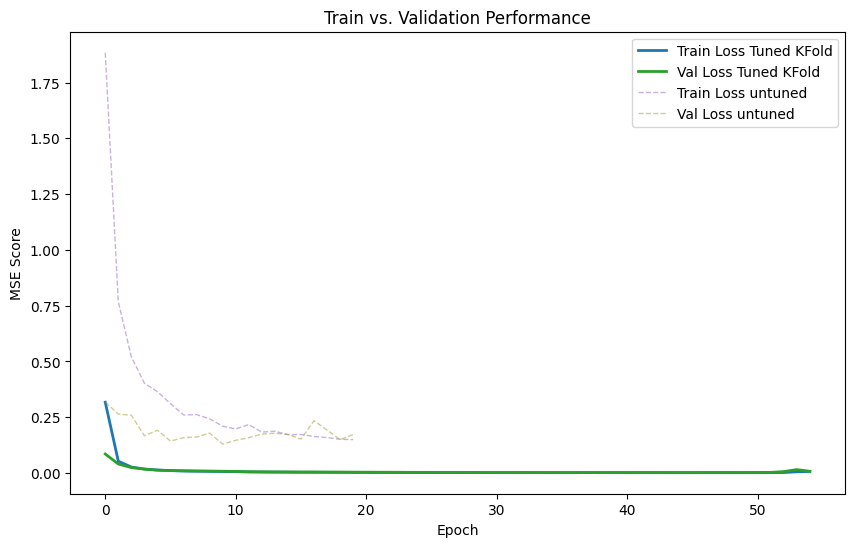

In [64]:
# Visualize the model performance:

plt.figure(figsize=(10, 6))

# Best performance model
plt.plot(mean_sum_train_loss_tuned_kfold, label='Train Loss Tuned KFold', linewidth=2, color='#1f77b4')
plt.plot(mean_val_train_loss_tuned_kfold, label='Val Loss Tuned KFold', linewidth=2, color='#2ca02c')

# Other models
# plt.plot(train_loss_tuned, label='Train Loss Tuned', linestyle='--', linewidth=1, color="#cf173c", alpha=0.5)
# plt.plot(val_loss_tuned, label='Val Loss Tuned', linestyle='--', linewidth=1, color='#ff7f0e', alpha=0.5)

plt.plot(train_loss_untuned, label='Train Loss untuned', linestyle='--', linewidth=1, color="#9467bd", alpha=0.5)
plt.plot(val_loss_unt uned, label='Val Loss untuned', linestyle='--', linewidth=1, color="#a09c2c", alpha=0.5)

plt.ylabel('MSE Score')
plt.xlabel('Epoch')
plt.title('Train vs. Validation Performance')
plt.legend()
plt.show()
plt.close()

In [ ]:
class test:
    def __init__(self):
        self.test = 'test'
    
    def callback(self, monitor, patieance, verbose, mode):
        es_callback = keras.callbacks.EarlyStopping(
            monitor=monitor,
            patience=patience,
            verbose=verbose,
            mode=mode
        )
        return es_callback
    
    def get_es_callback(self):
        return self.callback(monitor='val_loss', patience=10, verbose=1, mode='min')